In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from src.config import PROCESSED_DATA_PATH

In [3]:
df = pd.read_csv(PROCESSED_DATA_PATH)

In [4]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec,revol_bal,revol_util,total_acc,application_type,fico_score,loan_to_income,installment_to_income,credit_history_years,loan_default
0,3600.0,36 months,13.99,123.03,C,C4,10.0,MORTGAGE,55000.0,Not Verified,...,0.0,2765.0,29.7,13.0,Individual,677.0,0.065455,0.002237,12.334018,0
1,24700.0,36 months,11.99,820.28,C,C1,10.0,MORTGAGE,65000.0,Not Verified,...,0.0,21470.0,19.2,38.0,Individual,717.0,0.380000,0.012620,16.000000,0
2,20000.0,60 months,10.78,432.66,B,B4,10.0,MORTGAGE,63000.0,Not Verified,...,0.0,7869.0,56.2,18.0,Joint App,697.0,0.317460,0.006868,15.331964,0
3,10400.0,60 months,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,...,0.0,21929.0,64.5,35.0,Individual,697.0,0.099585,0.002776,17.500342,0
4,11950.0,36 months,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,...,0.0,8822.0,68.4,6.0,Individual,692.0,0.351471,0.011917,28.167009,0


In [5]:
df.shape

(1345310, 24)

In [6]:
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [7]:
df['term'] = df['term'].str.replace(' months', '').astype(int)

In [8]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec,revol_bal,revol_util,total_acc,application_type,fico_score,loan_to_income,installment_to_income,credit_history_years,loan_default
0,3600.0,36,13.99,123.03,C,C4,10.0,MORTGAGE,55000.0,Not Verified,...,0.0,2765.0,29.7,13.0,Individual,677.0,0.065455,0.002237,12.334018,0
1,24700.0,36,11.99,820.28,C,C1,10.0,MORTGAGE,65000.0,Not Verified,...,0.0,21470.0,19.2,38.0,Individual,717.0,0.380000,0.012620,16.000000,0
2,20000.0,60,10.78,432.66,B,B4,10.0,MORTGAGE,63000.0,Not Verified,...,0.0,7869.0,56.2,18.0,Joint App,697.0,0.317460,0.006868,15.331964,0
3,10400.0,60,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,...,0.0,21929.0,64.5,35.0,Individual,697.0,0.099585,0.002776,17.500342,0
4,11950.0,36,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,...,0.0,8822.0,68.4,6.0,Individual,692.0,0.351471,0.011917,28.167009,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345310 entries, 0 to 1345309
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   loan_amnt              1345310 non-null  float64
 1   term                   1345310 non-null  int64  
 2   int_rate               1345310 non-null  float64
 3   installment            1345310 non-null  float64
 4   grade                  1345310 non-null  object 
 5   sub_grade              1345310 non-null  object 
 6   emp_length             1266799 non-null  float64
 7   home_ownership         1345310 non-null  object 
 8   annual_inc             1345310 non-null  float64
 9   verification_status    1345310 non-null  object 
 10  purpose                1345310 non-null  object 
 11  dti                    1344936 non-null  float64
 12  delinq_2yrs            1345310 non-null  float64
 13  open_acc               1345310 non-null  float64
 14  pub_rec           

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1345310.0,14419.972014,8717.050787,500.000000,8000.000000,12000.000000,20000.000000,4.000000e+04
term,1345310.0,41.790196,10.268321,36.000000,36.000000,36.000000,36.000000,6.000000e+01
int_rate,1345310.0,13.239619,4.768716,5.310000,9.750000,12.740000,15.990000,3.099000e+01
installment,1345310.0,438.075533,261.512604,4.930000,248.480000,375.430000,580.730000,1.719830e+03
emp_length,1266799.0,5.965873,3.691166,0.000000,2.000000,6.000000,10.000000,1.000000e+01
annual_inc,1345310.0,76247.636414,69925.098427,0.000000,45780.000000,65000.000000,90000.000000,1.099920e+07
dti,1344936.0,18.282667,11.160446,-1.000000,11.790000,17.610000,24.060000,9.990000e+02
delinq_2yrs,1345310.0,0.317794,0.877992,0.000000,0.000000,0.000000,0.000000,3.900000e+01
open_acc,1345310.0,11.593520,5.473789,0.000000,8.000000,11.000000,14.000000,9.000000e+01
pub_rec,1345310.0,0.215276,0.601865,0.000000,0.000000,0.000000,0.000000,8.600000e+01


In [11]:
df['loan_default'].value_counts()

loan_default
0    1076751
1     268559
Name: count, dtype: int64

In [12]:
import pandas as pd

# Separate majority and minority classes
majority = df[df["loan_default"] == 0]
minority = df[df["loan_default"] == 1]

# Downsample majority class to match minority class size
majority_downsampled = majority.sample(
    n=len(minority),
    random_state=42
)

# Combine the downsampled majority with the minority class
df_balanced = pd.concat([majority_downsampled, minority])

# Shuffle the dataset
df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Check the new distribution
print(df_balanced["loan_default"].value_counts())

loan_default
1    268559
0    268559
Name: count, dtype: int64


In [13]:
df_balanced['loan_default'].value_counts()

loan_default
1    268559
0    268559
Name: count, dtype: int64

In [14]:
df = df_balanced

In [15]:
df['loan_default'].value_counts()

loan_default
1    268559
0    268559
Name: count, dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

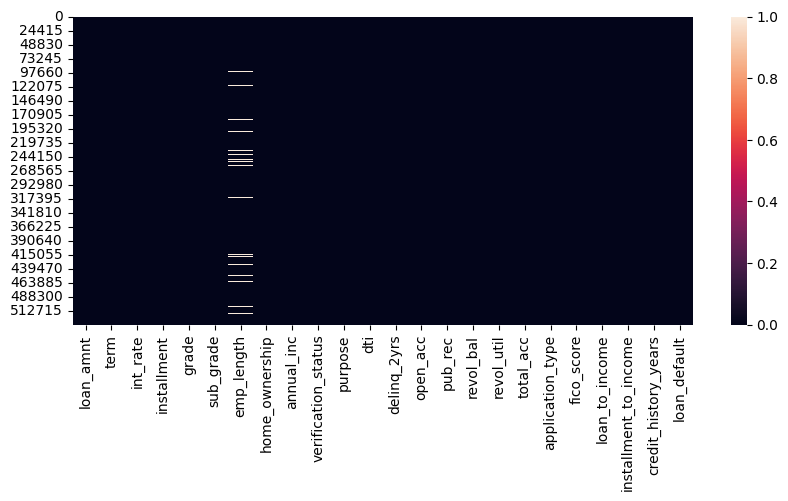

In [17]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull())
plt.show()

In [18]:
df.isnull().sum()

loan_amnt                    0
term                         0
int_rate                     0
installment                  0
grade                        0
sub_grade                    0
emp_length               35402
home_ownership               0
annual_inc                   0
verification_status          0
purpose                      0
dti                        154
delinq_2yrs                  0
open_acc                     0
pub_rec                      0
revol_bal                    0
revol_util                 356
total_acc                    0
application_type             0
fico_score                   0
loan_to_income             145
installment_to_income      145
credit_history_years         0
loan_default                 0
dtype: int64

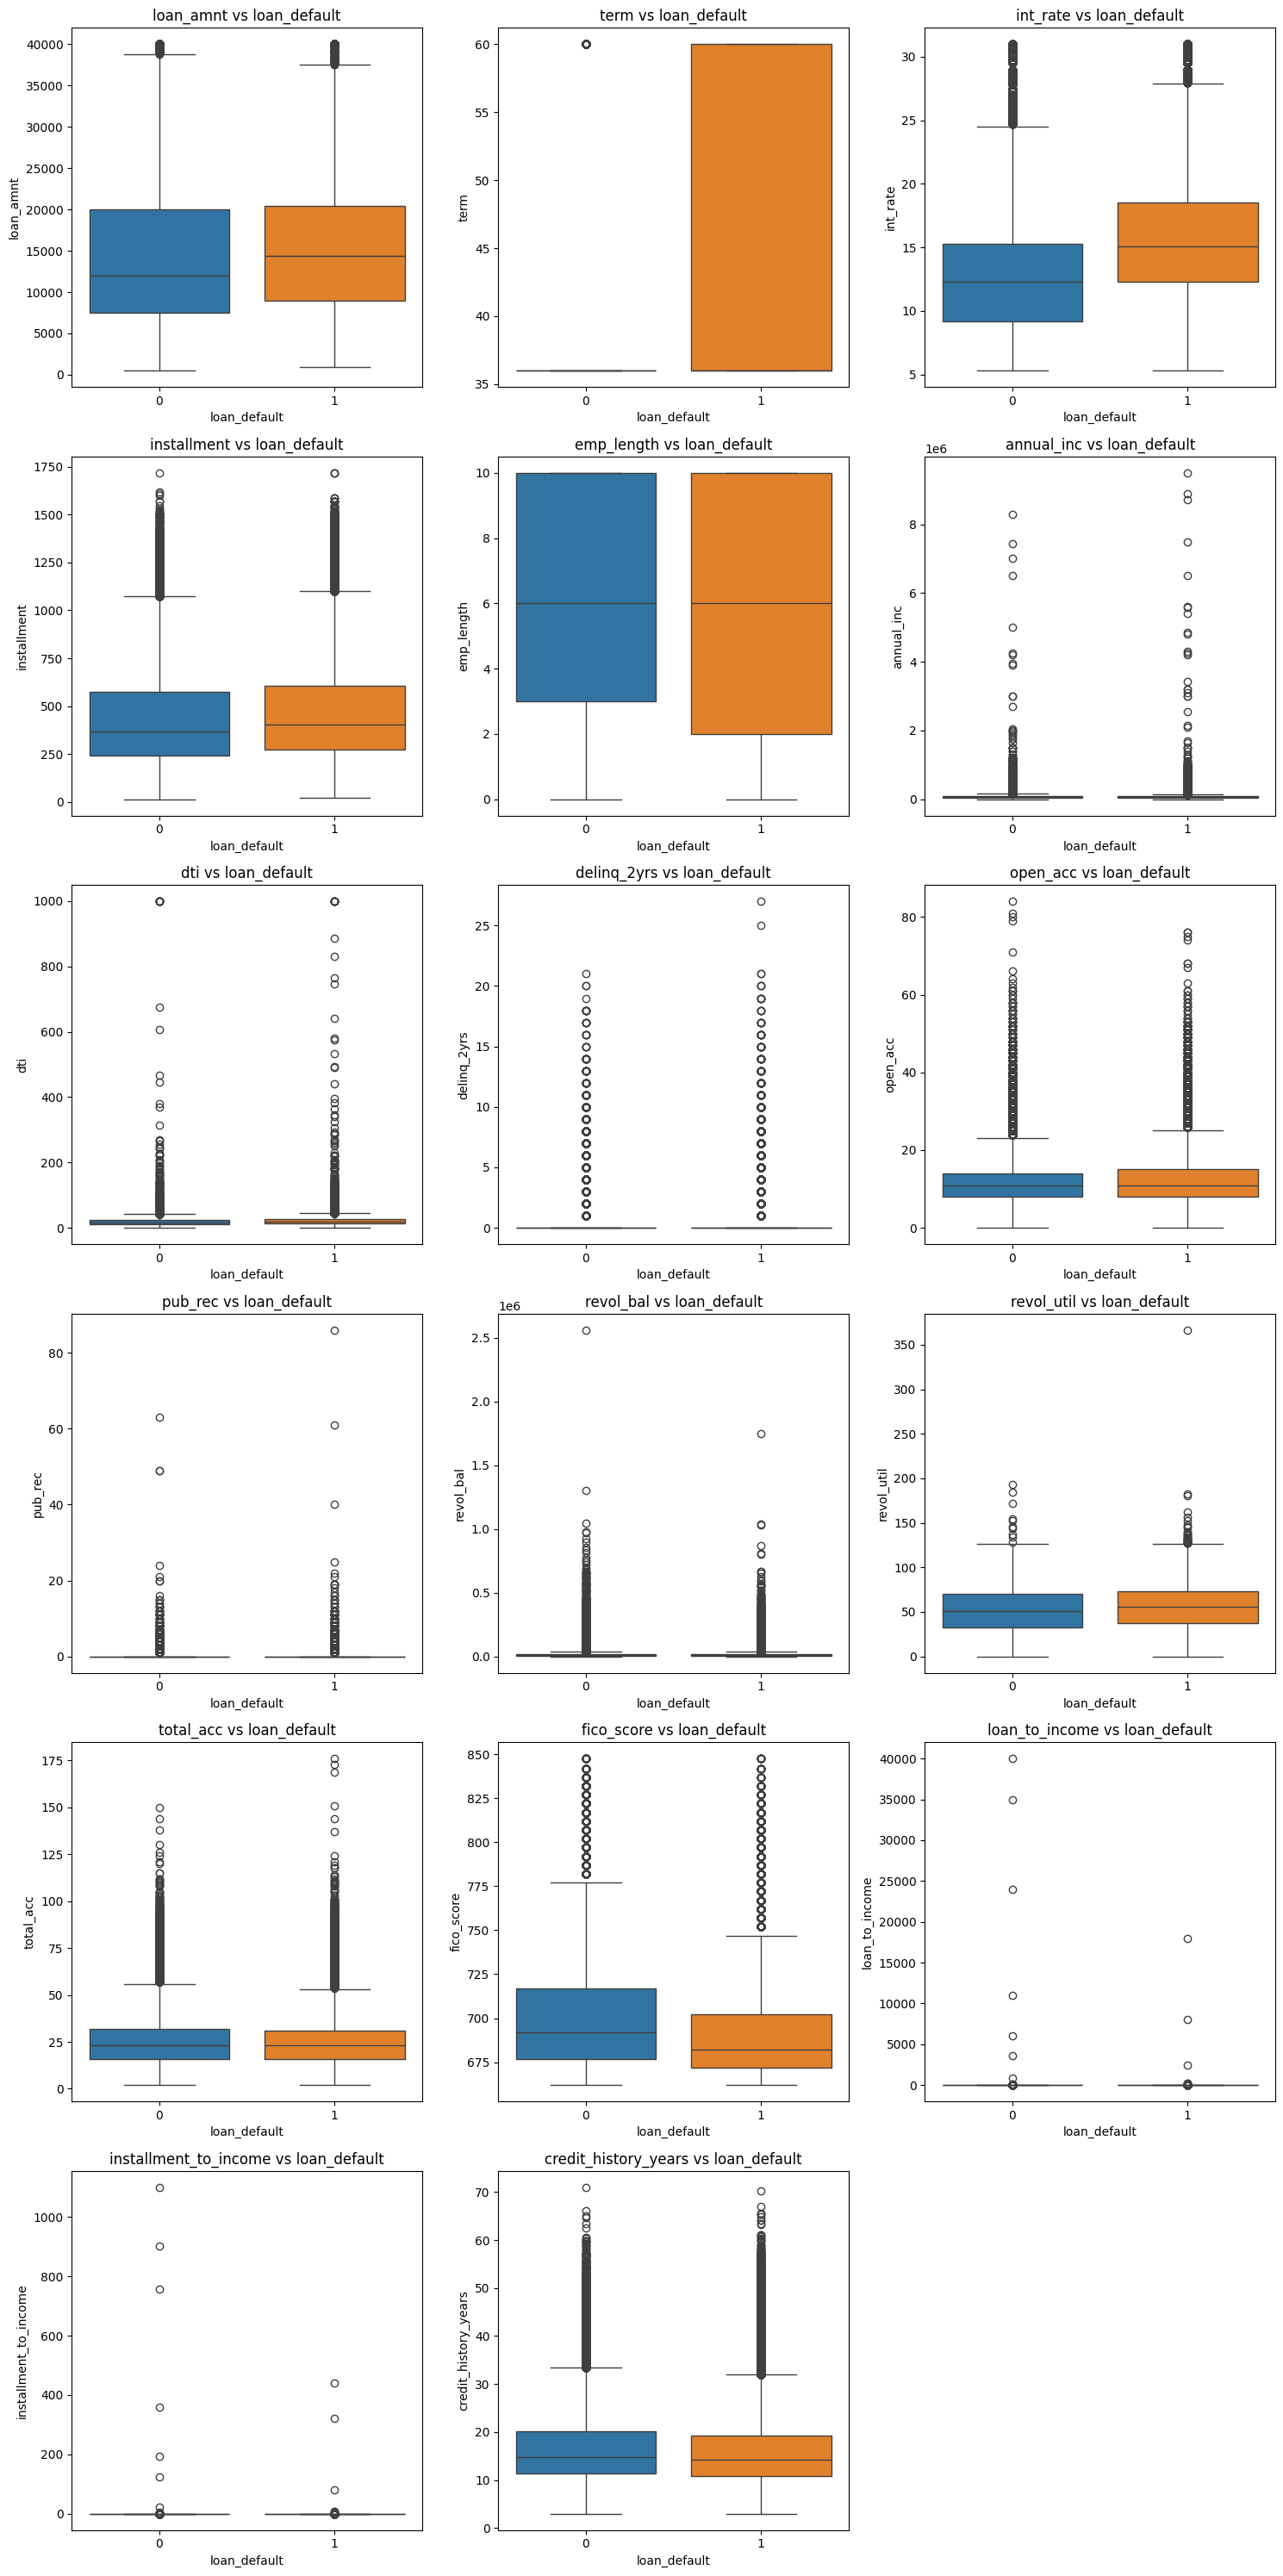

In [19]:
def show_outliers(a, target='loan_default'):

    numerical_cols = a.select_dtypes(include='number').columns
    numerical_cols = numerical_cols.drop(target, errors='ignore')

    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(15, 5 * n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):

        sns.boxplot(
            data=a,
            x=target,
            y=col,
            hue=target,
            legend=False,
            ax=axes[i]
        )

        axes[i].set_title(f'{col} vs {target}')
        axes[i].set_xlabel(target)
        axes[i].set_ylabel(col)

    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


show_outliers(df)

In [20]:
def count_outliers_by_class(df, target, num_col):

    result = []

    # Total observations
    total_rows = len(df)

    # Total observations in each class
    class_counts = df[target].value_counts()

    for cls in df[target].dropna().unique():

        data = df.loc[df[target] == cls, num_col].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Identify outliers
        outlier_mask = (data < lower) | (data > upper)

        outliers = outlier_mask.sum()

        # Total outliers across ALL classes will be calculated later
        result.append({
            'Class': cls,
            'Total': len(data),
            'Class_%_Of_Total': round(
                class_counts[cls] / total_rows * 100, 2
            ),
            'Q1': Q1,
            'Q3': Q3,
            'Lower_Bound': lower,
            'Upper_Bound': upper,
            'Outlier_Range': f'< {lower:.2f} OR > {upper:.2f}',
            'Outliers': outliers,
            'Outlier_%_Within_Class': round(
                outliers / len(data) * 100, 2
            )
        })

    result = pd.DataFrame(result)

    # Total number of outliers across all classes
    total_outliers = result['Outliers'].sum()

    # Percentage of all outliers belonging to each class
    result['Outlier_%_Of_All_Outliers'] = round(
        result['Outliers'] / total_outliers * 100, 2
    )

    return result

In [21]:
numerical_cols = df.select_dtypes(["int64", "float64","int32"])

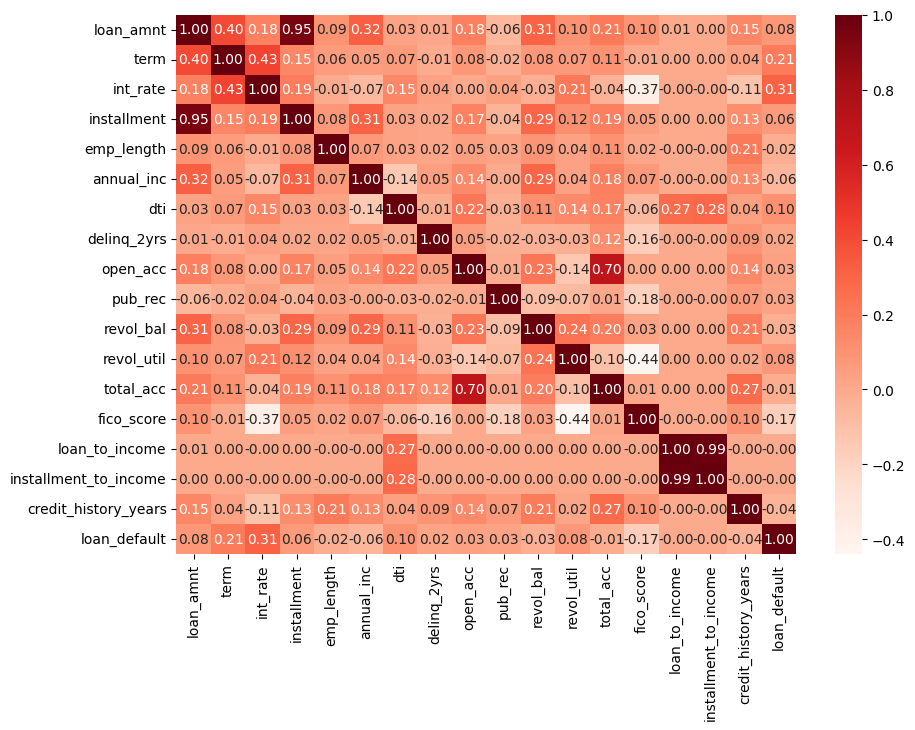

In [22]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    numerical_cols.corr(),
    annot=True,
    cmap='Reds',
    fmt='.2f'
)
plt.show()

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [24]:
from src.config import (
    PROCESSED_DATA_PATH,
    TARGET,
    TEST_SIZE,
    RANDOM_STATE,
)
from src.preprocessing import OutlierCapper

In [25]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)



# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# Preprocessing
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="passthrough"
)


# Models
models = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "random_forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "xgboost": XGBClassifier(
        random_state=RANDOM_STATE
        
    )
}


# Train each model
trained_models = {}

In [26]:
from sklearn.metrics import average_precision_score,roc_auc_score,confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report

In [27]:
for name, model in models.items():

    

    pipeline = Pipeline(
        steps=[
            ("outlier_capper", OutlierCapper()),
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_train_prob = pipeline.predict_proba(X_train)[:, 1]

    # Metrics
    train_accuracy = pipeline.score(X_train, y_train)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_prob)

    # Print results
    print(f"{name}")    
    print(f"Accuracy : {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1       : {train_f1:.4f}")
    print(f"ROC-AUC  : {train_roc_auc:.4f}")
    print("-" * 40)

logistic_regression
Accuracy : 0.6527
Precision: 0.6465
Recall   : 0.6738
F1       : 0.6599
ROC-AUC  : 0.7110
----------------------------------------
random_forest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
ROC-AUC  : 1.0000
----------------------------------------
xgboost
Accuracy : 0.6828
Precision: 0.6759
Recall   : 0.7025
F1       : 0.6889
ROC-AUC  : 0.7506
----------------------------------------


In [28]:
results = []

for name, model in trained_models.items():

    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob),
        "PR-AUC": average_precision_score(y_test, y_test_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
logistic_regression    0.6513     0.6446  0.6745 0.6592   0.7093  0.6909
      random_forest    0.6487     0.6454  0.6601 0.6527   0.7054  0.6820
            xgboost    0.6575     0.6507  0.6800 0.6650   0.7173  0.6975


In [29]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, confusion_matrix,
    recall_score, precision_score, f1_score, accuracy_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt

# Train/test split only - NO downsampling here.
# We tune with class_weight="balanced" instead, so we keep all the
# training data available to RandomizedSearchCV's CV folds.
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance (untouched):")
print(y_test.value_counts(normalize=True))

# Preprocessing (same as before)
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Stratified CV - preserves class ratio in every fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train class balance:
loan_default
0    0.5
1    0.5
Name: proportion, dtype: float64

Test class balance (untouched):
loan_default
1    0.5
0    0.5
Name: proportion, dtype: float64


In [30]:
# NOTE: step name must exactly match the prefix used in each param grid
# below (LR__, RF__, GBM__, XGB__) - that's what RandomizedSearchCV uses
# to route hyperparameters to the right step.

pipelines = {
    "logistic_regression": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("LR", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000))
    ]),
    "random_forest": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("RF", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    
    
    "xgboost": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("XGB", XGBClassifier(
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}

# Your existing param grids (unchanged, prefixes already match step names above)
param_range = [2, 3, 4, 5, 6]
param_range_fl = [0.6, 0.8, 1.0]
n_estimators = [50, 100, 150, 200, 300]
learning_rates = [0.01, 0.03, 0.05, 0.1]

param_grids = {
    
    "logistic_regression": {
        "LR__penalty": ["l1", "l2"],
        "LR__C": [0.01, 0.1, 0.5, 1.0, 10.0],
        "LR__solver": ["liblinear"]
    },
    "random_forest": {
        "RF__min_samples_leaf": [1, 2, 3, 5, 10],
        "RF__max_depth": param_range,
        "RF__min_samples_split": [2, 3, 4, 5, 10, 20],
        "RF__n_estimators": n_estimators,
        "RF__max_features": ["sqrt", "log2"]
    },
 
    
    "xgboost": {
        "XGB__learning_rate": learning_rates,
        "XGB__max_depth": param_range,
        "XGB__min_child_weight": [1, 2, 3, 5],
        "XGB__subsample": param_range_fl,
        "XGB__colsample_bytree": param_range_fl,
        "XGB__n_estimators": n_estimators
    }
}

In [31]:

# Evaluation metric
# F1 balances precision and recall for the positive/default class.
SCORING = "f1"

# Number of randomly sampled parameter combinations
N_ITER = 5


search_results = {}
best_estimators = {}


for name, pipeline in pipelines.items():

    print(f"\n{'=' * 60}")
    print(f"Tuning: {name}")
    print(f"{'=' * 60}")

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=N_ITER,
        scoring=SCORING,
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    # No GBM-specific sample_weight is needed anymore.
    search.fit(X_train, y_train)

    search_results[name] = search
    best_estimators[name] = search.best_estimator_

    print(f"Best CV {SCORING}: {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")


Tuning: logistic_regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.6597
Best params: {'LR__solver': 'liblinear', 'LR__penalty': 'l2', 'LR__C': 0.5}

Tuning: random_forest
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.6660
Best params: {'RF__n_estimators': 100, 'RF__min_samples_split': 5, 'RF__min_samples_leaf': 3, 'RF__max_features': 'log2', 'RF__max_depth': 5}

Tuning: xgboost
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.6679
Best params: {'XGB__subsample': 0.6, 'XGB__n_estimators': 300, 'XGB__min_child_weight': 2, 'XGB__max_depth': 5, 'XGB__learning_rate': 0.1, 'XGB__colsample_bytree': 1.0}


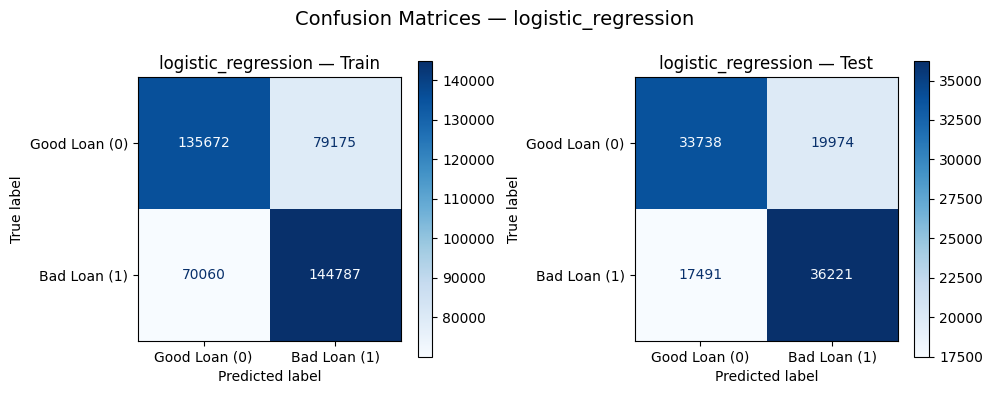

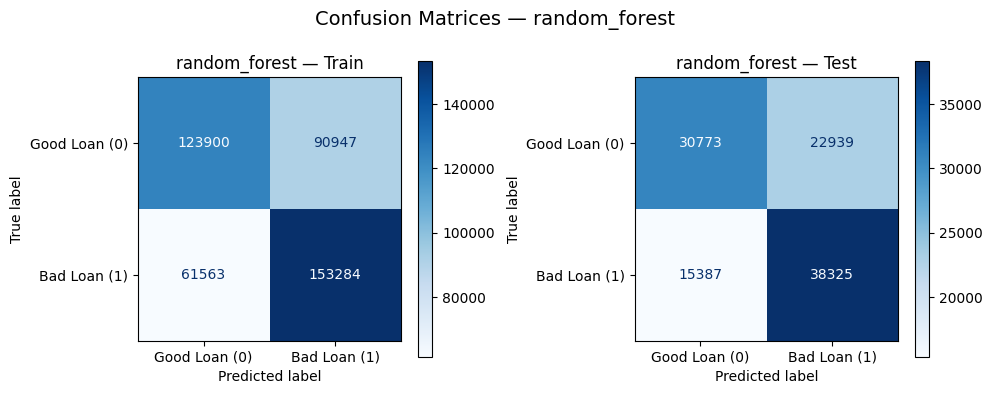

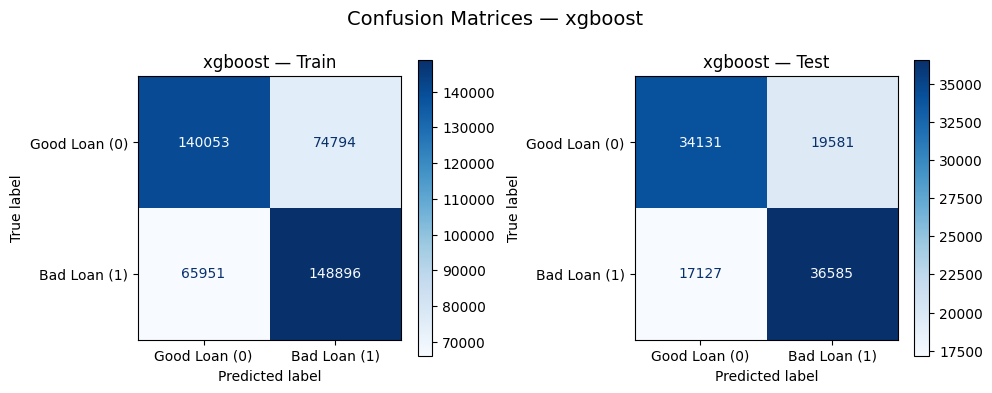


TRAIN SET RESULTS:
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
logistic_regression    0.6527     0.6465  0.6739 0.6599   0.7110  0.6934
      random_forest    0.6451     0.6276  0.7135 0.6678   0.7034  0.6848
            xgboost    0.6725     0.6656  0.6930 0.6791   0.7377  0.7250

TEST SET RESULTS:
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
logistic_regression    0.6512     0.6446  0.6744 0.6591   0.7093  0.6910
      random_forest    0.6432     0.6256  0.7135 0.6667   0.7010  0.6803
            xgboost    0.6583     0.6514  0.6811 0.6659   0.7199  0.7016


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

CLASS_NAMES = ["Good Loan (0)", "Bad Loan (1)"]

train_results = []
test_results = []

for name, model in best_estimators.items():

    # =========================
    # Predictions: TRAIN
    # =========================
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    # =========================
    # Predictions: TEST
    # =========================
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # Store TRAIN metrics
    # =========================
    train_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred),
        "Recall": recall_score(y_train, y_train_pred),
        "F1": f1_score(y_train, y_train_pred),
        "ROC-AUC": roc_auc_score(y_train, y_train_prob),
        "PR-AUC": average_precision_score(y_train, y_train_prob)
    })

    # =========================
    # Store TEST metrics
    # =========================
    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob),
        "PR-AUC": average_precision_score(y_test, y_test_prob)
    })

    # =========================
    # Train and Test Confusion
    # Matrices Side by Side
    # =========================
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ConfusionMatrixDisplay(
        confusion_matrix(y_train, y_train_pred),
        display_labels=CLASS_NAMES
    ).plot(ax=axes[0], cmap="Blues", values_format="d")

    axes[0].set_title(f"{name} — Train")

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_test_pred),
        display_labels=CLASS_NAMES
    ).plot(ax=axes[1], cmap="Blues", values_format="d")

    axes[1].set_title(f"{name} — Test")

    fig.suptitle(f"Confusion Matrices — {name}", fontsize=14)
    plt.tight_layout()
    plt.show()


# ==========================================
# Create Train and Test Result DataFrames
# ==========================================

train_results_df = pd.DataFrame(train_results)
test_results_df = pd.DataFrame(test_results)


# ==========================================
# Display Train Results
# ==========================================

print("\nTRAIN SET RESULTS:")
print(train_results_df.round(4).to_string(index=False))


# ==========================================
# Display Test Results
# ==========================================

print("\nTEST SET RESULTS:")
print(test_results_df.round(4).to_string(index=False))

In [33]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt

# Best XGBoost model from RandomizedSearchCV

best_xgb = Pipeline(steps=[
    ("outlier_capper", OutlierCapper()),
    ("preprocessor", preprocessor),
    ("XGB", XGBClassifier(
        subsample=0.6,
        n_estimators=300,
        min_child_weight= 2,
        max_depth = 5,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        learning_rate =  0.1,
        colsample_bytree = 1.0,
        n_jobs=-1,
    ))
])

best_xgb.fit(X_train, y_train)


# =========================
# TRAIN SET
# =========================
y_train_pred = best_xgb.predict(X_train)
y_train_proba = best_xgb.predict_proba(X_train)[:, 1]

print("=" * 60)
print("XGBOOST - TRAINING SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_train,
        y_train_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_train, y_train_proba):.4f}")


XGBOOST - TRAINING SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.68      0.65      0.67    214847
 Bad Loan (1)       0.67      0.69      0.68    214847

     accuracy                           0.67    429694
    macro avg       0.67      0.67      0.67    429694
 weighted avg       0.67      0.67      0.67    429694

Confusion Matrix:
[[140053  74794]
 [ 65951 148896]]

Metrics:
Accuracy : 0.6725
Precision: 0.6656
Recall   : 0.6930
F1       : 0.6791
ROC-AUC  : 0.7377


In [34]:
# =========================
# TEST SET
# =========================
y_test_pred = best_xgb.predict(X_test)
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("XGBOOST - TEST SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.4f}")




XGBOOST - TEST SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.67      0.64      0.65     53712
 Bad Loan (1)       0.65      0.68      0.67     53712

     accuracy                           0.66    107424
    macro avg       0.66      0.66      0.66    107424
 weighted avg       0.66      0.66      0.66    107424

Confusion Matrix:
[[34131 19581]
 [17127 36585]]

Metrics:
Accuracy : 0.6583
Precision: 0.6514
Recall   : 0.6811
F1       : 0.6659
ROC-AUC  : 0.7199


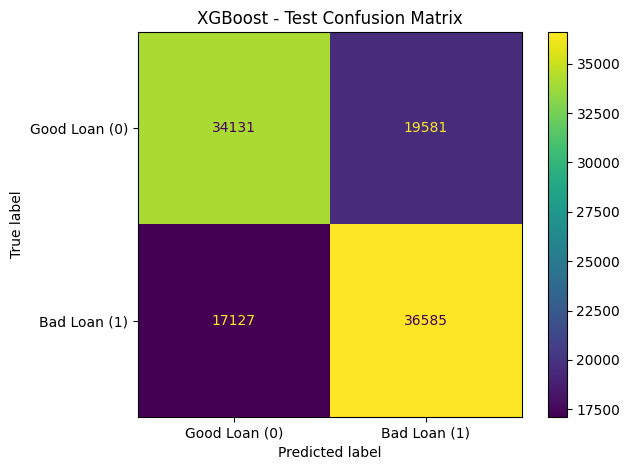

In [35]:
# =========================
# CONFUSION MATRIX PLOT
# =========================
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Good Loan (0)", "Bad Loan (1)"],
    values_format="d"
)

plt.title("XGBoost - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt

# Best Logistic Regression params from RandomizedSearchCV:
# {'LR__solver': 'liblinear', 'LR__penalty': 'l2', 'LR__C': 0.5}
best_lr = Pipeline(steps=[
    ("outlier_capper", OutlierCapper()),
    ("preprocessor", preprocessor),
    ("LR", LogisticRegression(
        solver="liblinear",
        penalty="l2",
        C=0.5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=2000
    ))
])

best_lr.fit(X_train, y_train)

# =========================
# TRAIN SET
# =========================
y_train_pred = best_lr.predict(X_train)
y_train_proba = best_lr.predict_proba(X_train)[:, 1]

print("=" * 60)
print("LOGISTIC REGRESSION - TRAINING SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_train,
        y_train_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_train, y_train_proba):.4f}")

LOGISTIC REGRESSION - TRAINING SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.66      0.63      0.65    214847
 Bad Loan (1)       0.65      0.67      0.66    214847

     accuracy                           0.65    429694
    macro avg       0.65      0.65      0.65    429694
 weighted avg       0.65      0.65      0.65    429694

Confusion Matrix:
[[135672  79175]
 [ 70060 144787]]

Metrics:
Accuracy : 0.6527
Precision: 0.6465
Recall   : 0.6739
F1       : 0.6599
ROC-AUC  : 0.7110


In [37]:
# =========================
# TEST SET
# =========================
y_test_pred = best_lr.predict(X_test)
y_test_proba = best_lr.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION - TEST SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.4f}")



LOGISTIC REGRESSION - TEST SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.66      0.63      0.64     53712
 Bad Loan (1)       0.64      0.67      0.66     53712

     accuracy                           0.65    107424
    macro avg       0.65      0.65      0.65    107424
 weighted avg       0.65      0.65      0.65    107424

Confusion Matrix:
[[33738 19974]
 [17491 36221]]

Metrics:
Accuracy : 0.6512
Precision: 0.6446
Recall   : 0.6744
F1       : 0.6591
ROC-AUC  : 0.7093


In [38]:
# Best Random Forest params from RandomizedSearchCV:
# {'RF__n_estimators': 300, 'RF__min_samples_split': 5,
#  'RF__min_samples_leaf': 5, 'RF__max_features': 'log2', 'RF__max_depth': 6}
best_rf = Pipeline(steps=[
    ("outlier_capper", OutlierCapper()),
    ("preprocessor", preprocessor),
    ("RF", RandomForestClassifier(
        n_estimators=100,
        min_samples_split=5,
        min_samples_leaf=3,
        max_features="log2",
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

best_rf.fit(X_train, y_train)

# =========================
# TRAIN SET
# =========================
y_train_pred = best_rf.predict(X_train)
y_train_proba = best_rf.predict_proba(X_train)[:, 1]

print("=" * 60)
print("RANDOM FOREST - TRAINING SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_train,
        y_train_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_train, y_train_proba):.4f}")

RANDOM FOREST - TRAINING SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.67      0.58      0.62    214847
 Bad Loan (1)       0.63      0.71      0.67    214847

     accuracy                           0.65    429694
    macro avg       0.65      0.65      0.64    429694
 weighted avg       0.65      0.65      0.64    429694

Confusion Matrix:
[[123900  90947]
 [ 61563 153284]]

Metrics:
Accuracy : 0.6451
Precision: 0.6276
Recall   : 0.7135
F1       : 0.6678
ROC-AUC  : 0.7034


In [39]:
# =========================
# TEST SET
# =========================
y_test_pred = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("RANDOM FOREST - TEST SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.4f}")



RANDOM FOREST - TEST SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.67      0.57      0.62     53712
 Bad Loan (1)       0.63      0.71      0.67     53712

     accuracy                           0.64    107424
    macro avg       0.65      0.64      0.64    107424
 weighted avg       0.65      0.64      0.64    107424

Confusion Matrix:
[[30773 22939]
 [15387 38325]]

Metrics:
Accuracy : 0.6432
Precision: 0.6256
Recall   : 0.7135
F1       : 0.6667
ROC-AUC  : 0.7010


In [ ]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec,revol_bal,revol_util,total_acc,application_type,fico_score,loan_to_income,installment_to_income,credit_history_years,loan_default
0,10000.0,36,8.18,314.20,B,B1,10.0,MORTGAGE,80000.0,Verified,...,0.0,27196.0,86.3,13.0,Individual,687.0,0.125000,0.003927,9.828884,1
1,11575.0,60,20.49,309.84,E,E2,8.0,RENT,44170.0,Source Verified,...,0.0,8281.0,82.8,26.0,Individual,667.0,0.262056,0.007015,12.169747,0
2,16575.0,36,13.18,559.92,C,C3,4.0,RENT,95000.0,Not Verified,...,1.0,8773.0,34.0,47.0,Individual,677.0,0.174474,0.005894,29.752225,0
3,16000.0,60,13.99,372.21,C,C3,2.0,RENT,50000.0,Source Verified,...,3.0,13160.0,83.8,6.0,Individual,662.0,0.320000,0.007444,5.169062,1
4,20000.0,60,16.29,489.45,D,D2,10.0,MORTGAGE,83000.0,Source Verified,...,0.0,6441.0,38.1,24.0,Individual,697.0,0.240964,0.005897,12.084873,1


In [42]:
!pip install shap

     -------------------------------------- 547.2/547.2 KB 5.8 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 8.6 MB/s eta 0:00:00
  Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)
     ---------------------------------------- 28.1/28.1 MB 6.0 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Data Science\DataScience_Projects\lending_club_default_risk_project\myenv\Scripts\python.exe -m pip install --upgrade pip' command.


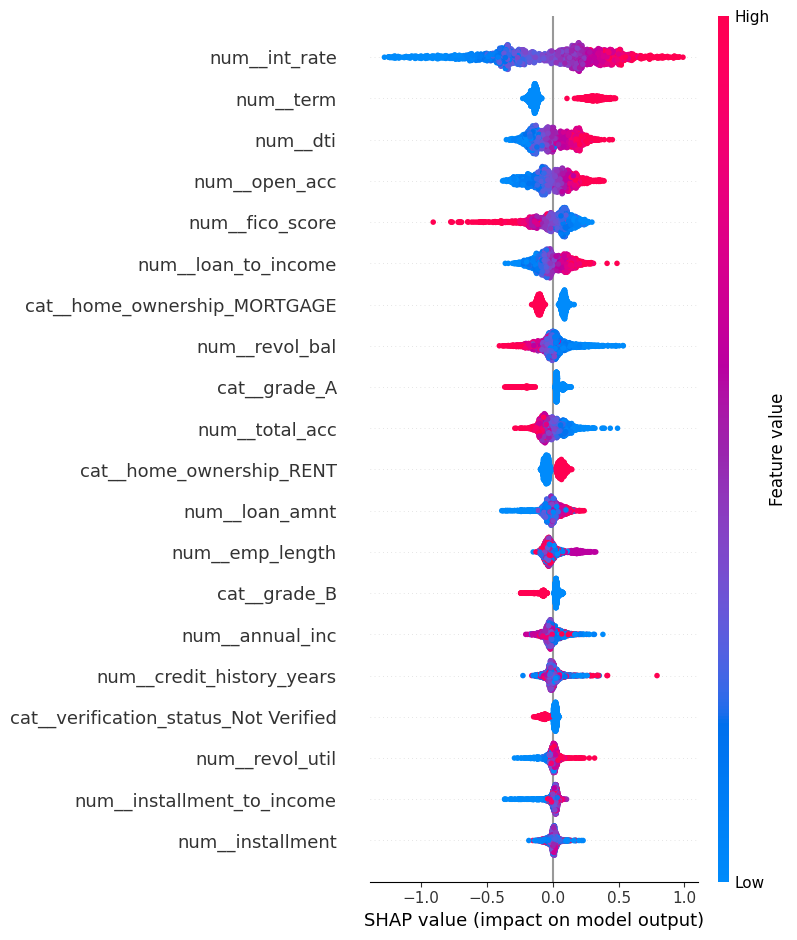

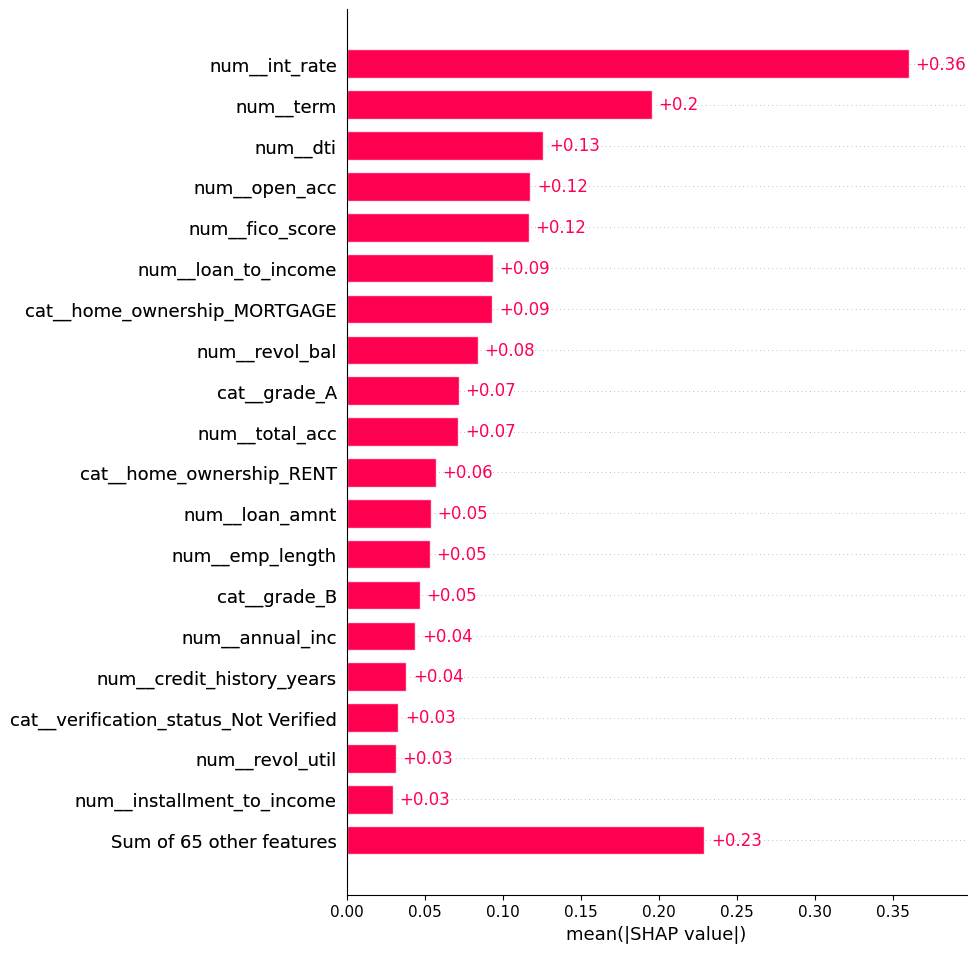

In [45]:
import shap
import pandas as pd

# Transform data through preprocessing steps only (not the model step) -
# SHAP needs the data in the same form the model actually sees it.
X_test_capped = best_xgb.named_steps["outlier_capper"].transform(X_test)
X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test_capped)
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# SHAP on the full test set can be slow - sample for a stable, fast global view
sample_df = X_test_shap.sample(n=min(2000, len(X_test_shap)), random_state=RANDOM_STATE)

# Extract the actual XGBoost model from the pipeline
xgb_model = best_xgb.named_steps["XGB"]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(sample_df)

# =========================
# GLOBAL SUMMARY PLOT
# =========================
# One dot per (row, feature). Position = impact on prediction (toward
# default vs no-default). Color = the feature's actual value (high/low).
shap.summary_plot(shap_values, sample_df, max_display=20)

# =========================
# GLOBAL FEATURE IMPORTANCE (mean |SHAP value|)
# =========================
# Simpler ranked view - which features matter most overall, regardless
# of direction.
shap.plots.bar(shap_values, max_display=20)